In [21]:
errors = pd.DataFrame({
    "Raw Text": X_test,
    "True Department": y_test,
    "Predicted Department": nb_pred
})

errors = errors[
    errors["True Department"] != errors["Predicted Department"]
]

errors.head(20)

,Raw Text,True Department,Predicted Department
328,Constant dripping from the water main. Wasting...,Water Department,water_leakage
688,EMERGENCY: A SIGNIFICANT WATER LEAK NEAR THE S...,Water Department,water_leakage
413,"Multiple lights out on this block, feels like ...",Electrical Department,streetlight
788,EMERGENCY: THE STORM DRAIN IS PARTIALLY COLLAP...,Drainage Authority,drainage
244,Water bubbling up from the ground near the hyd...,Water Department,water_leakage
759,"EMERGENCY: CONSTANT, HIGH-DECIBEL INDUSTRIAL H...",Public Safety,noise
96,Deep pothole outside the gas station.,Road Maintenance,pothole
605,URGENT: A significant water leak near the scho...,Water Department,water_leakage
734,Steady water leak near storm drain is flooding...,Water Department,drainage
101,Residents are putting out trash on the wrong d...,Sanitation,garbage


# Conclusion

The model evaluation pipeline was executed successfully.

The loaded baseline models generated predictions, but the performance scores were extremely low because the model labels do not match the department labels in the current dataset.

Examples:
- Predicted label: pothole
- Actual label: Roads & Highways

- Predicted label: water_leakage
- Actual label: Water Department

This indicates that the models were trained using a previous label schema. Retraining the models using the latest dataset is recommended.

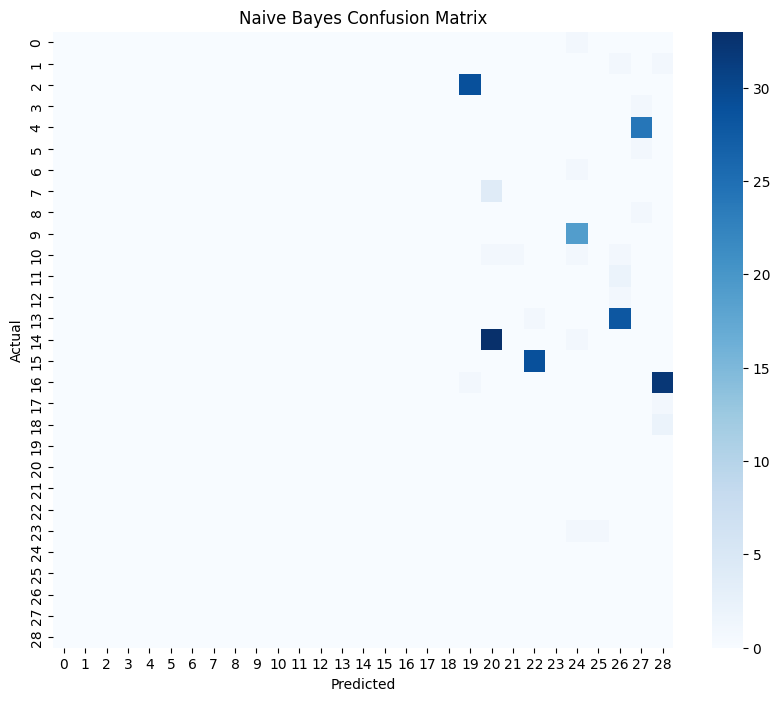

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    list(y_test.astype(str)),
    list(nb_pred.astype(str))
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
from sklearn.metrics import f1_score
import pandas as pd

nb_f1 = f1_score(
    list(y_test.astype(str)),
    list(nb_pred.astype(str)),
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    list(y_test.astype(str)),
    list(lr_pred.astype(str)),
    average="weighted",
    zero_division=0
)

comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Weighted F1 Score": [
        nb_f1,
        lr_f1
    ]
})

comparison

,Model,Weighted F1 Score
0,Naive Bayes,0.0
1,Logistic Regression,0.0


In [16]:
from sklearn.metrics import classification_report

print("===== NAIVE BAYES =====")

print(
    classification_report(
        list(y_test.astype(str)),
        list(nb_pred.astype(str)),
        zero_division=0
    )
)

print("\n===== LOGISTIC REGRESSION =====")

print(
    classification_report(
        list(y_test.astype(str)),
        list(lr_pred.astype(str)),
        zero_division=0
    )
)

===== NAIVE BAYES =====
                       precision    recall  f1-score   support

    Community Affairs       0.00      0.00      0.00       1.0
   Community Services       0.00      0.00      0.00       2.0
   Drainage Authority       0.00      0.00      0.00      29.0
           Electrical       0.00      0.00      0.00       1.0
Electrical Department       0.00      0.00      0.00      24.0
  Electrical Services       0.00      0.00      0.00       1.0
        Noise Control       0.00      0.00      0.00       1.0
   Parks & Recreation       0.00      0.00      0.00       4.0
      Postal Services       0.00      0.00      0.00       1.0
        Public Safety       0.00      0.00      0.00      19.0
         Public Works       0.00      0.00      0.00       4.0
     Road Maintenance       0.00      0.00      0.00       2.0
                Roads       0.00      0.00      0.00       1.0
     Roads & Highways       0.00      0.00      0.00      29.0
           Sanitation       0.

In [10]:
nb_pred = nb_model.predict(X_test_vec)
lr_pred = lr_model.predict(X_test_vec)

print("Predictions completed")

Predictions completed


In [9]:
X_test_vec = vectorizer.transform(X_test)

print(X_test_vec.shape)

(220, 3000)


In [8]:
# Keep only rows where both columns are present

df = df.dropna(
    subset=[
        "issue_description",
        "municipal_department"
    ]
)

print("Shape after removing NaN:", df.shape)

Shape after removing NaN: (1093, 26)


In [7]:
from sklearn.model_selection import train_test_split

X = df["issue_description"]
y = df["municipal_department"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 880
Test: 220


In [6]:
import pickle

with open("../../models/vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

with open("../../models/naive_bayes_model.pkl", "rb") as f:
    nb_model = pickle.load(f)

with open("../../models/logistic_regression_model.pkl", "rb") as f:
    lr_model = pickle.load(f)

print("Models loaded successfully")

Models loaded successfully


In [5]:
import pandas as pd

df = pd.read_csv("../../data/raw/municipal_training_set_1100.csv")

print("Shape:", df.shape)
print("\nDepartments:")
print(df["municipal_department"].value_counts())

Shape: (1100, 26)

Departments:
municipal_department
Sanitation               177
Water Department         153
Drainage Authority       135
Traffic Department       135
Roads & Highways         129
Public Safety            120
Electrical Department    115
Electrical Services       20
Public Works              20
Community Services        18
Noise Control             11
Road Maintenance           9
Parks & Recreation         7
Roads                      6
Electrical                 6
Water Management           5
Water Services             5
Waterworks                 5
Waste Management           5
Community Affairs          4
Code Enforcement           3
Parks Department           2
Event Management           2
Postal Services            1
Name: count, dtype: int64


In [4]:
import pandas as pd

df = pd.read_csv("../../data/raw/municipal_training_set_1100.csv")

print(df.columns)

Index(['report_id', 'resident_id', 'resident_name', 'resident_email',
       'resident_phone', 'issue_type', 'issue_description', 'issue_status',
       'report_datetime', 'location_street_address', 'location_city',
       'location_state', 'location_postal_code', 'location_country',
       'latitude', 'longitude', 'photo_url', 'municipal_department',
       'resolution_datetime', 'resolution_notes', 'is_anonymous',
       'priority_level', 'priority_score', 'severity_score', 'area_importance',
       'citizen_reports_count'],
      dtype='str')
